In [43]:
import networkx as nx
import asymmetree.treeevolve as te
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import random

from asymmetree.visualization.tree_vis import visualize, assign_colors
from asymmetree.analysis import orthology_from_tree, bmg_from_tree
from tralda.datastructures.tree import TreeNode
from insert_hybrid import insertHybrid

{22: array([1.        , 0.49803922, 0.05490196, 1.        ]), 23: array([1.        , 0.49803922, 0.05490196, 1.        ]), 24: array([1.        , 0.49803922, 0.05490196, 1.        ]), 25: array([1.        , 0.49803922, 0.05490196, 1.        ]), 26: array([1.        , 0.49803922, 0.05490196, 1.        ]), 38: array([1.        , 0.49803922, 0.05490196, 1.        ]), 39: array([1.        , 0.49803922, 0.05490196, 1.        ]), 35: array([1.        , 0.49803922, 0.05490196, 1.        ]), 36: array([1.        , 0.49803922, 0.05490196, 1.        ]), 32: array([1.        , 0.49803922, 0.05490196, 1.        ]), 33: array([1.        , 0.49803922, 0.05490196, 1.        ]), 15: array([1.        , 0.49803922, 0.05490196, 1.        ]), 16: array([1.        , 0.49803922, 0.05490196, 1.        ]), 13: array([1.        , 0.49803922, 0.05490196, 1.        ]), 30: array([0.12156863, 0.46666667, 0.70588235, 1.        ]), 31: array([0.12156863, 0.46666667, 0.70588235, 1.        ]), 27: array([0.12156863, 

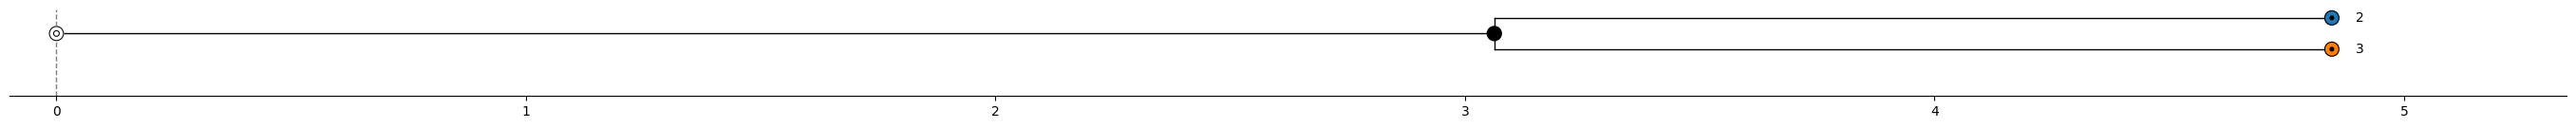

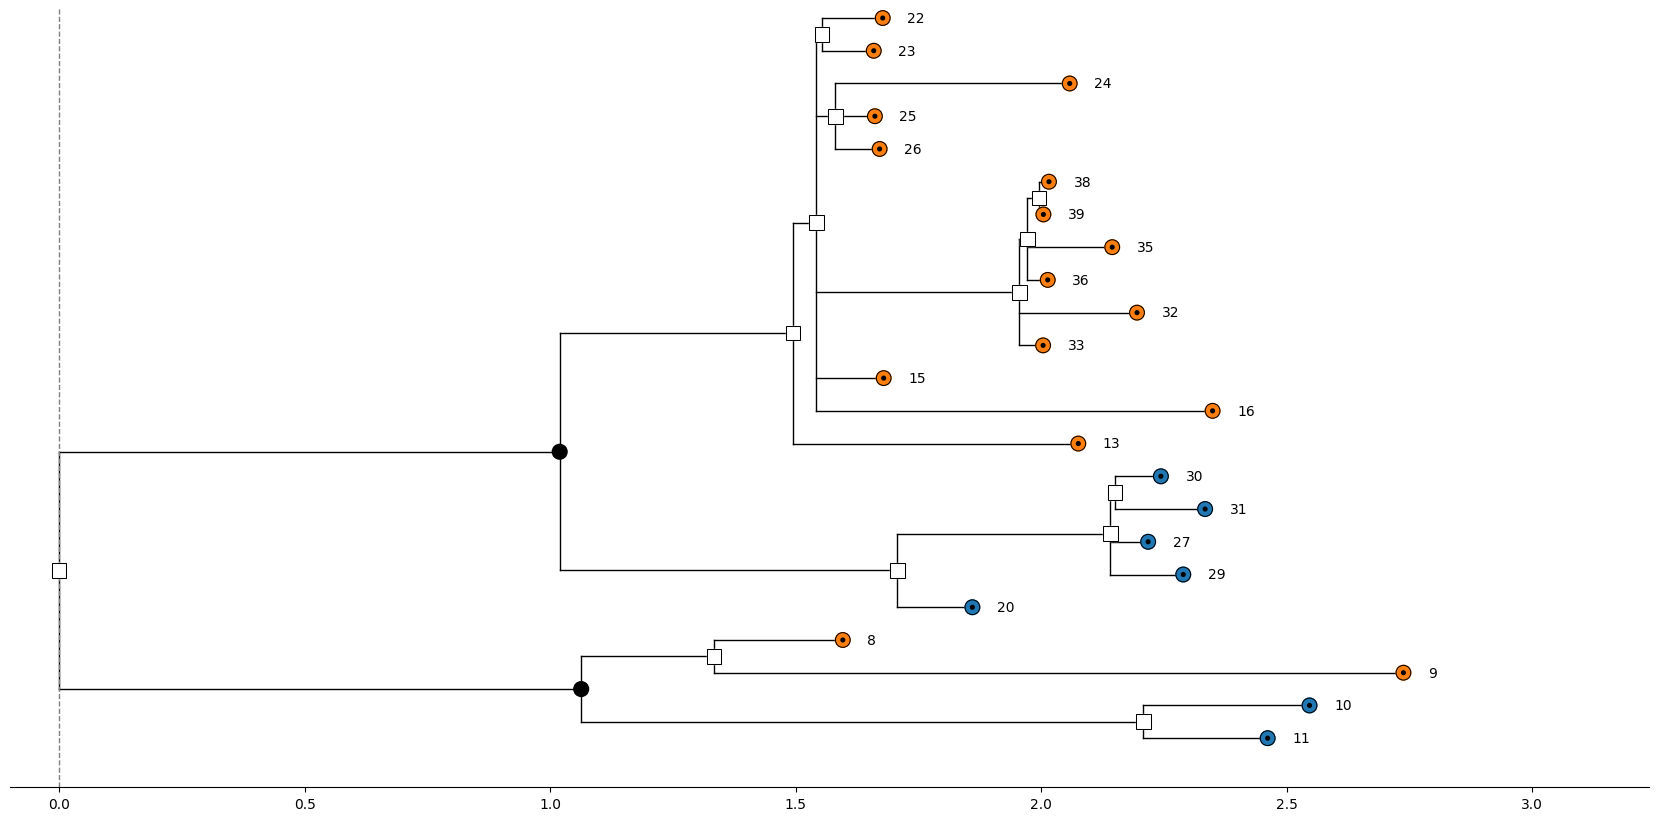

In [44]:
# Zufälligen Genbaum von Assymetree erstellen lassen.
# generate Species Tree

S = te.species_tree_n(n = 2)

# generate Gene Tree

dated_gene_tree = te.dated_gene_tree(
    S,
    dupl_rate=0.5,
    loss_rate=0.1,
    hgt_rate=0,
    dupl_polytomy=0.5
)

full_gene_tree = te.rate_heterogeneity(
    dated_gene_tree,
    S,
    base_rate=0.5,
    autocorr_variance=0.2,
)

# prune all loss branches and the planted root
pruned_gene_tree = te.prune_losses(full_gene_tree)

species_colors, gene_colors = assign_colors(S, dated_gene_tree)

print(gene_colors)

visualize(S, color_dict=species_colors)

# visualize(dated_gene_tree, color_dict=gene_colors)
# visualize(full_gene_tree, color_dict=gene_colors)
visualize(pruned_gene_tree, color_dict=gene_colors)

In [45]:
### Erster Ansatz:
# über max(dist) den Zeitbereich herausfinden 
# nicht unbedingt nötig, wenn man einfach eine zufällige Kante auswählt und diese nur mit einer Node verbindet, die niedriger ist als der Timestamp der neuen Node
# timerange = max(nx.get_node_attributes(N,"tstamp").values())
# random Zeitpunkt auswählen
# time = random.uniform(0,timerange)
# edges finden, die zu dieser Zeit existiert haben.
# possibleEdges = set(edge for edge in N.edges if N.nodes[edge[0]]["tstamp"] >= time and N.nodes[edge[1]]["tstamp"] <= time)

In [46]:
def hierarchy_pos(G, root, level_gap=1.0, node_gap=1.0):
    pos = {}
    def _pos(node, x, y, width):
        pos[node] = (y, G.nodes[node]["tstamp"])
        children = list(G.successors(node))
        if children:
            dx = width / len(children)
            x_start = x - width/2 + dx/2
            for n,child in enumerate(children):
                _pos(child,1 * n, x_start, dx)
                x_start += dx
    _pos(root, 0, 0, node_gap * len(G.nodes))
    return pos

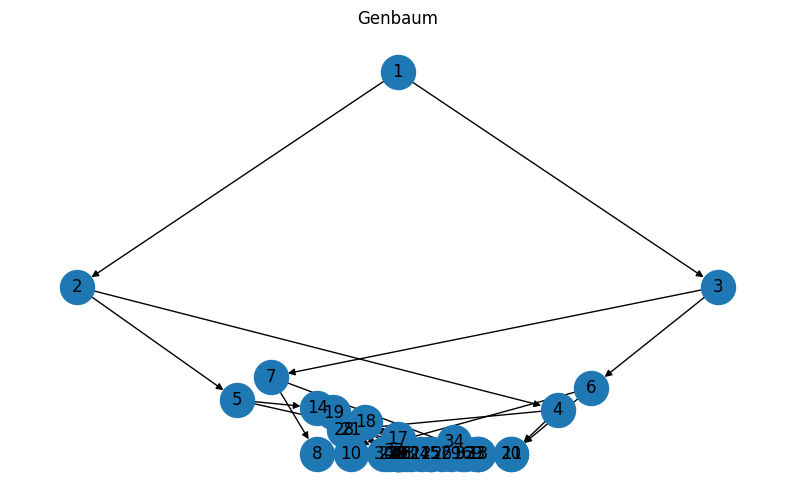

In [47]:
N, root = pruned_gene_tree.to_nx()

# ── Labels: node.label Attribut ──────────────────────────
labels = {n: N.nodes[n]['label'] for n in N.nodes}

pos = hierarchy_pos(N, root)

fig, ax = plt.subplots(figsize=(10, 6))

nx.draw(N,pos= pos,
        labels=labels,
        # node_color=node_colors,
        node_size=600,
        arrows=True,
        ax=ax)

plt.title('Genbaum')
plt.show()

Edge zwischen 21 und 27 ausgewählt
Node 11 ausgewählt


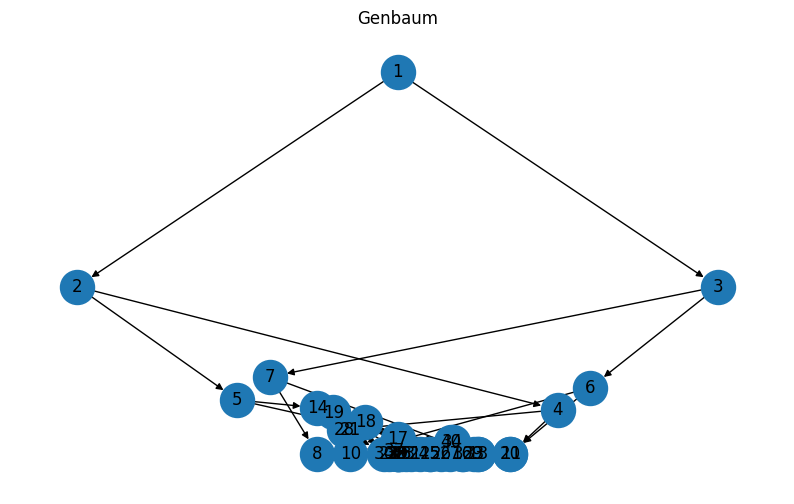

[(2022511778288, {'label': 1, 'event': 'D', 'reconc': (0, 1), 'tstamp': 4.071911776028416, 'transferred': 0, 'dist': 0.0}), (2022511783248, {'label': 2, 'event': 'S', 'reconc': 1, 'tstamp': 1.7837488858394348, 'transferred': 0, 'dist': np.float64(1.019498801502309), 'sibling_nr': 0}), (2022511773328, {'label': 5, 'event': 'D', 'reconc': (1, 3), 'tstamp': 0.5752062503474581, 'transferred': 0, 'dist': np.float64(0.47511356462014614), 'sibling_nr': 0}), (2022511774608, {'label': 14, 'event': 'D', 'reconc': (1, 3), 'tstamp': 0.49153993921531713, 'transferred': 0, 'dist': np.float64(0.04749017273258228), 'sibling_nr': 0}), (2022511785168, {'label': 19, 'event': 'D', 'reconc': (1, 3), 'tstamp': 0.44418977715487756, 'transferred': 0, 'dist': np.float64(0.011642083226661425), 'sibling_nr': 0}), (2022511777808, {'label': 22, 'event': 'S', 'reconc': 3, 'tstamp': 0.0, 'transferred': 0, 'dist': np.float64(0.1236680051588777), 'sibling_nr': 0}), (2022511785008, {'label': 23, 'event': 'S', 'reconc':

In [ ]:
label = max(nx.get_node_attributes(N,"label").values())+1

# eine zufällige Edge auswählen, diese durch einen Hybrid erweitern.

randomEdge = random.choice(list(N.edges))

N.remove_edge(randomEdge[0],randomEdge[1])

tstampHybrid = (N.nodes[randomEdge[0]]["tstamp"] + N.nodes[randomEdge[1]]["tstamp"])/2
distHybrid = (N.nodes[randomEdge[0]]["dist"] + N.nodes[randomEdge[1]]["dist"])/2

N.add_node(label,
            label = label,
            event = 'H',
            reconc = N.nodes[randomEdge[0]]["reconc"], # gibt an zu welcher Spezies es gehört nochmal herausfinden, was genau zeine Liste an dieser Stelle bedeutet
            tstamp = tstampHybrid,
            # transferred = ,
            dist = distHybrid
            )

N.add_edges_from([(randomEdge[0],label),(label,randomEdge[1])])

print("Edge zwischen",N.nodes[randomEdge[0]]["label"],"und",N.nodes[randomEdge[1]]["label"],"ausgewählt")
# Zufällige Node auswählen, die Anforderungen erfüllt.

randomNode = random.choice(list(node for node in N.nodes 
                            if N.nodes[node]["dist"]>0                                  # Node "jünger" als Hybrid ###### dist vsa. tstamp???
                            and N.nodes[node]["reconc"] != N.nodes[label]["reconc"]     # Node andere Spezies als Hybrid
                            and N.predecessors(node) != randomEdge[0]                   # Node hat nicht den parent als parent
                            and N.predecessors(node) != randomEdge[1]                   # Node hat nicht das child als parent
                            and node != randomEdge[1]))  

if not randomNode:
    print("es wurde keine passende Node gefunden")

print("Node",N.nodes[randomNode]["label"], "ausgewählt")
    
# Node mit Hybrid verbinden

N.add_edge(label,randomNode)

# ── Labels: node.label Attribut ──────────────────────────
labels = {n: N.nodes[n]['label'] for n in N.nodes}

pos = hierarchy_pos(N, root)

# # ── Farben: nach reconc (Spezies) ────────────────────────
# # Alle einzigartigen Spezies-IDs sammeln
# species = list(set(N.nodes[n]['reconc'] for n in N.nodes))

# # Jeder Spezies eine Farbe zuweisen
# cmap = cm.get_cmap('tab10', len(species))
# species_color = {s: cmap(i) for i, s in enumerate(species)}

# node_colors = [species_color[N.nodes[n]['reconc']] for n in N.nodes]


# ── Plot ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

nx.draw(N,pos= pos,
        labels=labels,
        # node_color=node_colors,
        node_size=600,
        arrows=True,
        ax=ax)

plt.title('Genbaum')
plt.show()
print(N.nodes(data=True))

In [49]:
insertHybrid(N)

# ── Labels: node.label Attribut ──────────────────────────
labels = {n: N.nodes[n]['label'] for n in N.nodes}

pos = hierarchy_pos(N, root)

# # ── Farben: nach reconc (Spezies) ────────────────────────
# # Alle einzigartigen Spezies-IDs sammeln
# species = list(set(N.nodes[n]['reconc'] for n in N.nodes))

# # Jeder Spezies eine Farbe zuweisen
# cmap = cm.get_cmap('tab10', len(species))
# species_color = {s: cmap(i) for i, s in enumerate(species)}

# node_colors = [species_color[N.nodes[n]['reconc']] for n in N.nodes]


# ── Plot ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

nx.draw(N,pos= pos,
        labels=labels,
        # node_color=node_colors,
        node_size=600,
        arrows=True,
        ax=ax)

plt.title('Genbaum')
plt.show()

# for node in G.nodes(data=True):
#     print(node)

TypeError: 'int' object is not subscriptable